<a href="https://colab.research.google.com/github/erlanggajuni45/classification-image/blob/main/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Klasifikasi Gambar: [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)
- **Nama:** Erlangga Juni Saputra
- **Email:** junisaputraerlangga@gmail.com
- **ID Dicoding:** erlanggajuni45

## Import Semua Packages/Library yang Digunakan

In [15]:
!pip install kagglehub
!pip install tensorflowjs

In [24]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflowjs as tfjs

import tensorflow as tf

from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization

## Data Preparation

### Data Loading

In [28]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Dataset Intel berhasil diunduh ke:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset Intel berhasil diunduh ke: /kaggle/input/intel-image-classification


### Data Preprocessing

#### Split Dataset

In [50]:
train_dir = os.path.join(path, 'seg_train', 'seg_train')
test_dir = os.path.join(path, 'seg_test', 'seg_test')

In [51]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2,
    validation_split=0.15
)

In [52]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [53]:
train_generator = train_datagen.flow_from_directory(
  train_dir,
  target_size=(150, 150),
  batch_size=64,
  class_mode='categorical',
  subset='training',
  seed=42
)

Found 11932 images belonging to 6 classes.


In [29]:
val_generator = train_datagen.flow_from_directory(
  train_dir,
  target_size=(150, 150),
  batch_size=64,
  class_mode='categorical',
  subset='validation',
  seed=42
)

Found 2102 images belonging to 6 classes.


In [30]:
test_generator = test_datagen.flow_from_directory(
  test_dir,
  target_size=(150, 150),
  batch_size=64,
  class_mode='categorical',
  shuffle=False
)

Found 3000 images belonging to 6 classes.


## Modelling

In [31]:
model = Sequential([
    Input(shape=(150, 150, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(train_generator.num_classes, activation='softmax')
])

In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,012,806 (42.01 MB)

 Trainable params: 11,010,822 (42.00 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [34]:
class TargetCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if logs.get('accuracy') > 0.96 and logs.get('val_accuracy') > 0.96:
      print("\nAkurasi training & validasi telah mencapai > 96%")
      self.model.stop_training = True

callbacks = [
    TargetCallback(),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
]

In [35]:
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 117s 557ms/step - accuracy: 0.6414 - loss: 1.0441 - val_accuracy: 0.2269 - val_loss: 3.7160 - learning_rate: 0.0010
Epoch 2/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 89s 478ms/step - accuracy: 0.7434 - loss: 0.7154 - val_accuracy: 0.3758 - val_loss: 2.3517 - learning_rate: 0.0010
Epoch 3/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 89s 475ms/step - accuracy: 0.7737 - loss: 0.6147 - val_accuracy: 0.6147 - val_loss: 1.0855 - learning_rate: 0.0010
Epoch 4/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 89s 474ms/step - accuracy: 0.8061 - loss: 0.5354 - val_accuracy: 0.7655 - val_loss: 0.6521 - learning_rate: 0.0010
Epoch 5/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 89s 474ms/step - accuracy: 0.8234 - loss: 0.4987 - val_accuracy: 0.7460 - val_loss: 0.7091 - learning_rate: 0.0010
Epoch 6/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 89s 474ms/step - accuracy: 0.8269 - loss: 0.4722 - val_accuracy: 0.7950 - val_loss: 0.5719 - learning_rate: 0.0010
Epoch 7/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 90s 479ms/step - accuracy: 0.

## Evaluasi dan Visualisasi

In [38]:
test_loss, test_accuracy = model.evaluate(test_generator)

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8760 - loss: 0.3787


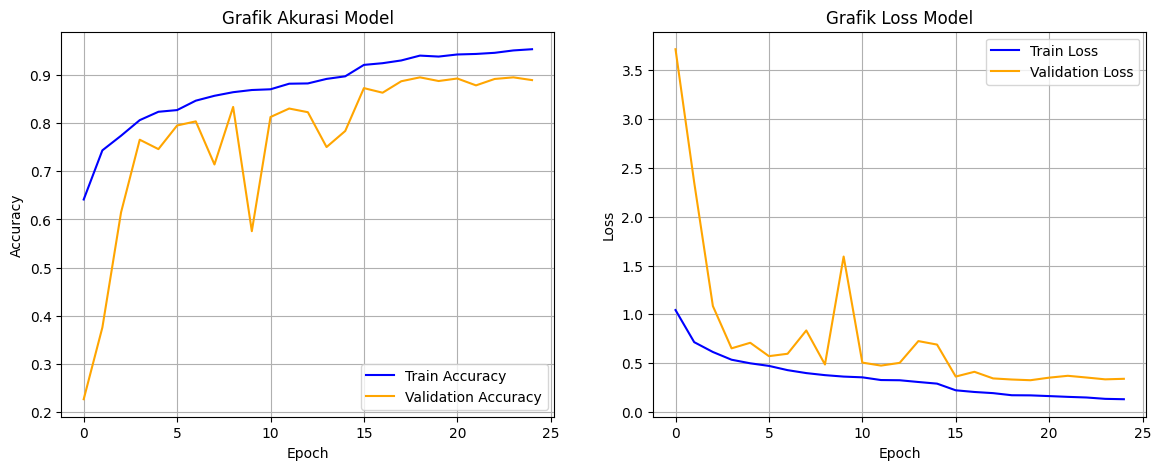

In [39]:
plt.figure(figsize=(14, 5))

# plot akurasi
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Grafik Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Grafik Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

## Konversi Model

In [39]:
save_path = 'saved_model/'
tf.saved_model.save(model, save_path)
print("Model berhasil disimpan di:", save_path)

Model berhasil disimpan di: saved_model/


In [40]:
converter = tf.lite.TFLiteConverter.from_saved_model(save_path)
converter.experimental_new_converter = True
tflite_model = converter.convert()

os.makedirs('tflite', exist_ok=True)
with open('tflite/model.tflite', 'wb') as f:
  f.write(tflite_model)
print('TF-Lite berhasil disimpan')

TF-Lite berhasil disimpan


In [54]:
labels = sorted(list(train_generator.class_indices.keys()))
with open('tflite/label.txt', 'w') as f:
  for label in labels:
    f.write(label + '\n')
print('label berhasil dibuat')

label berhasil dibuat


In [23]:
tfjs.converters.convert_tf_saved_model(
    saved_model_dir='saved_model/',
    output_dir='tfjs_model'
)
print('Model berhasil dikonversi ke format JSON')

Model berhasil dikonversi ke format JSON


## Inference (Optional)

In [42]:
interpreter = tf.lite.Interpreter(model_path="tflite/model.tflite")
interpreter.allocate_tensors()

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [43]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [44]:
pred_dir = os.path.join(path, 'seg_pred', 'seg_pred')
sample_image_name = os.listdir(pred_dir)[0]
img_path = os.path.join(pred_dir, sample_image_name)

In [45]:
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0).astype(np.float32)


In [47]:
interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

In [55]:
predicted_class_idx = np.argmax(output_data)
predicted_label = labels[predicted_class_idx]

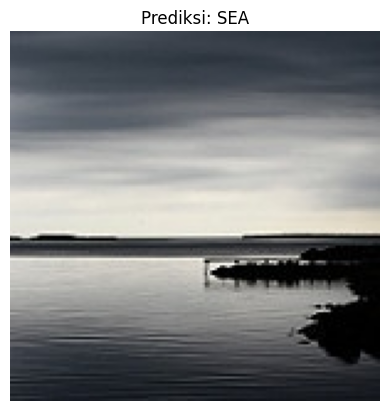

In [56]:
plt.imshow(img)
plt.title(f"Prediksi: {predicted_label.upper()}")
plt.axis('off')
plt.show()